In [1]:
import os

print("CWD:", os.getcwd())
print("Files in ../data:", os.listdir("../data"))

CWD: C:\Users\Misha\Desktop\ecommerce_analysis\notebooks
Files in ../data: ['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


Загружаем 4 основные таблицы

In [2]:
import pandas as pd

orders = pd.read_csv("../data/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
customers = pd.read_csv("../data/olist_customers_dataset.csv")

print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("payments:", payments.shape)
print("customers:", customers.shape)

orders.head(3)

orders: (99441, 8)
order_items: (112650, 7)
payments: (103886, 5)
customers: (99441, 5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


Пропуски в ключевых таблицах

In [5]:
orders.isna().sum().sort_values(ascending=False).head(10)

order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_estimated_delivery_date       0
dtype: int64

Делаем первый график (заказы по месяцам)

C:\Users\Misha\AppData\Local\Temp\ipykernel_1444\3669080753.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  orders.set_index("order_purchase_timestamp").resample("M").size().plot(figsize=(12,5))


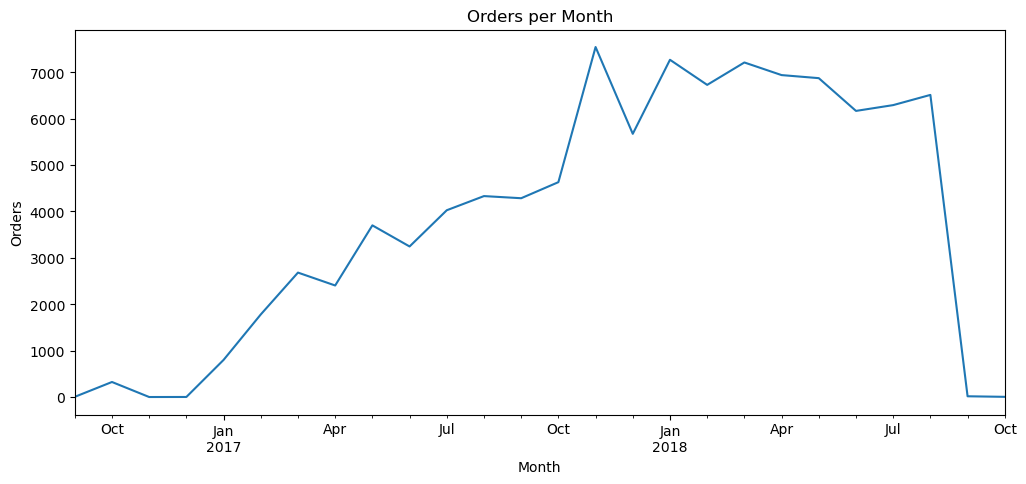

In [6]:
import matplotlib.pyplot as plt

orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

orders.set_index("order_purchase_timestamp").resample("M").size().plot(figsize=(12,5))
plt.title("Orders per Month")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()

Считаем выручку и средний чек (AOV)

In [7]:
df_pay = payments.groupby("order_id", as_index=False)["payment_value"].sum()

total_revenue = df_pay["payment_value"].sum()
aov = df_pay["payment_value"].mean()

print(f"Total revenue: {total_revenue:,.2f}")
print(f"AOV (avg order value): {aov:,.2f}")

Total revenue: 16,008,872.12
AOV (avg order value): 160.99


Соединяем заказы + оплаты и смотрим выручку по месяцам

C:\Users\Misha\AppData\Local\Temp\ipykernel_1444\1237121131.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rev_month = rev_month.set_index("order_purchase_timestamp").resample("M")["payment_value"].sum()


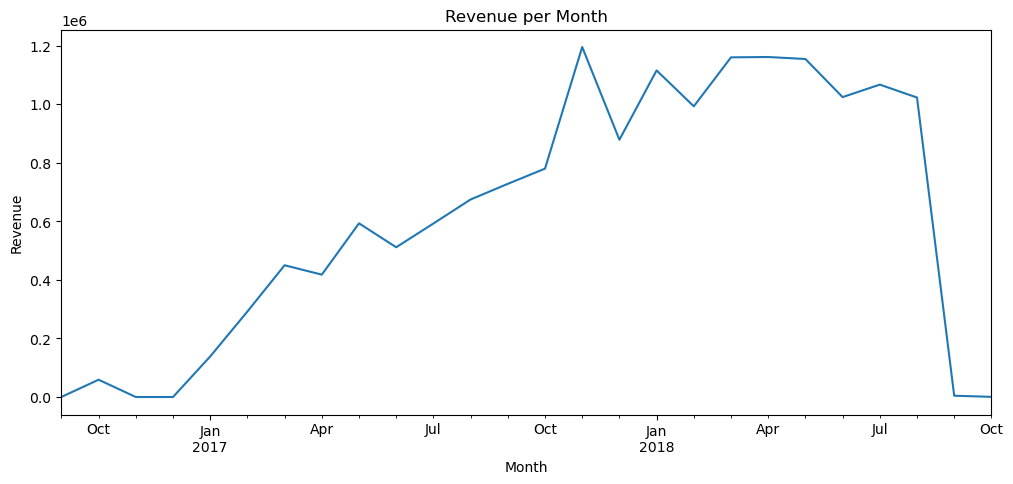

In [8]:
rev_month = orders[["order_id", "order_purchase_timestamp"]].merge(df_pay, on="order_id", how="inner")
rev_month = rev_month.set_index("order_purchase_timestamp").resample("M")["payment_value"].sum()

rev_month.plot(figsize=(12,5))
plt.title("Revenue per Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()